# Brain state statistics (K-medoids, K = 5)

This notebook performs subject-level statistical analyses on brain state features derived from k-medoids clustering of wSMI connectivity, inspired by the approach in Della Bella et al.

The key steps are:

1. Load subject×condition features:
   - state occupancies \(p_i\) for \(K = 5\)
   - weighted entropy (WE)
   - occupancy entropy \(H(p)\) and its normalized version \(H_{\text{occ\_norm}}\).
2. Define high-entropy and low-entropy state groups based on state entropies \(H_i\).
3. Compute descriptive statistics (mean, SEM, 95% CI) for each condition.
4. Perform within-subject statistical tests across conditions for:
   - WE
   - \(H_{\text{occ\_norm}}\)
   - high-entropy occupancy \(p_\text{high}\)
   - low-entropy occupancy \(p_\text{low}\)
5. Visualise brain state occupancy profiles across states and conditions.


In [ ]:
from pathlib import Path  # For robust path handling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # For higher-level plotting
from scipy import stats  # For statistical tests

# Plotting style configuration
sns.set(style="whitegrid", context="talk")  # Use a clean, publication-style theme
plt.rcParams["figure.figsize"] = (10, 6)  # Set a default figure size

# Paths (notebook is assumed to live in notebooks/ at repo root)
FEATURES_CSV = "../data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/states_features_k_medoids/features_subject_condition_k5.csv"  # Path to subject×condition features
STATE_ENTROPIES_PATH = "../data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/states_features_k_medoids/state_entropies_k5.npy"  # Path to state entropies H_i

# Load features CSV
df = pd.read_csv(FEATURES_CSV)  # Load subject×condition features into a DataFrame

# Basic sanity printout
print("Shape of features DataFrame:", df.shape)  # Show number of rows and columns
print("Columns:", df.columns.tolist())  # List all column names
print("Unique subjects:", df["subject"].nunique())  # Count unique subjects
print("Conditions and counts:")  # Announce condition counts
print(df["condition_name"].value_counts())  # Show how many rows per condition

# Ensure subject and condition_name are treated consistently as strings
df["subject"] = df["subject"].astype(str)  # Cast subject IDs to string
df["condition_name"] = df["condition_name"].astype(str)  # Cast condition names to string

# Inspect the first few rows
df.head()  # Display top rows for inspection


Shape of features DataFrame: (225, 12)
Columns: ['subject', 'condition', 'p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'WE', 'H_occ', 'H_occ_norm', 'n_windows', 'condition_name']
Unique subjects: 75
Conditions and counts:
condition_name
Familiar voice    75
Medical staff     75
Resting           75
Name: count, dtype: int64


,subject,condition,p_0,p_1,p_2,p_3,p_4,WE,H_occ,H_occ_norm,n_windows,condition_name
0,0,0,0.0,0.0,0.600000,0.400000,0.0,2.118537,0.673012,0.418166,10,Familiar voice
1,0,1,0.0,0.0,0.200000,0.800000,0.0,2.132007,0.500402,0.310918,10,Medical staff
2,0,2,0.0,0.0,0.666667,0.333333,0.0,2.116292,0.636514,0.395488,3,Resting
3,1,0,0.0,0.0,0.200000,0.500000,0.3,2.157336,1.029653,0.639759,10,Familiar voice
4,1,1,0.0,0.0,0.200000,0.200000,0.6,2.182665,0.950271,0.590436,10,Medical staff


## State entropies and derived occupancy measures

In this section, state entropies $H_i$ are loaded and used to define:

- **High-entropy states**: the two states with the highest $H_i$.
- **Low-entropy states**: the two states with the lowest $H_i$.

For each subject×condition, two aggregate occupancy measures are then computed:

- $p_\text{high}$: summed occupancy over high-entropy states.
- $p_\text{low}$: summed occupancy over low-entropy states.

These quantities mirror the idea of contrasting more complex vs. more stereotyped brain states.


In [243]:
# Load state entropies H_i
H_i = np.load(STATE_ENTROPIES_PATH)  # Load vector of state entropies

# Sanity check on shape
print("H_i shape:", H_i.shape)  # Expect (5,) for K=5
print("H_i values:", H_i)  # Display entropy values for inspection

# Sort states by entropy in descending order (high -> low)
state_indices = np.arange(len(H_i))  # Indices 0..K-1
sorted_idx_desc = np.argsort(H_i)[::-1]  # Indices sorted by H_i from high to low

print("States sorted by entropy (high -> low):")  # Announce ordering
for rank, idx in enumerate(sorted_idx_desc, start=1):  # Iterate over sorted indices
    print(f" Rank {rank}: state {idx} with H_i = {H_i[idx]:.3f}")  # Print rank and entropy

# Define high-entropy and low-entropy state sets (top-2 and bottom-2)
high_entropy_states = sorted_idx_desc[:2]  # Two highest-entropy states
low_entropy_states = sorted_idx_desc[-2:]  # Two lowest-entropy states

print("High-entropy states:", high_entropy_states)  # Show high-entropy state indices
print("Low-entropy states:", low_entropy_states)  # Show low-entropy state indices

# Helper function: compute aggregate occupancy over a set of states
def aggregate_occupancy(row, state_indices_subset):
    """Compute the sum of p_i for a given row over a subset of state indices."""
    # Build the column names for the selected states
    cols = [f"p_{int(i)}" for i in state_indices_subset]  # Construct p_i column names
    return row[cols].sum()  # Sum occupancies over selected states

# Compute p_high and p_low for each row
df["p_high"] = df.apply(lambda row: aggregate_occupancy(row, high_entropy_states), axis=1)  # Add high-entropy occupancy
df["p_low"] = df.apply(lambda row: aggregate_occupancy(row, low_entropy_states), axis=1)  # Add low-entropy occupancy

# Check that p_0..p_4 sum to approximately 1 for each row
p_cols = [col for col in df.columns if col.startswith("p_") and col[2:].isdigit()]  # Detect occupancy columns p_0..p_4
sum_p = df[p_cols].sum(axis=1)  # Sum occupancies across states
max_deviation = np.abs(sum_p - 1.0).max()  # Maximum deviation from 1
print("Max deviation of sum(p_i) from 1.0:", max_deviation)  # Show normalisation quality

# Display a preview of relevant columns
df[["subject", "condition_name"] + p_cols + ["p_high", "p_low"]].head()  # Inspect main occupancy columns


H_i shape: (5,)
H_i values: [2.24997807 2.17437604 2.10506716 2.13874245 2.22317164]
States sorted by entropy (high -> low):
 Rank 1: state 0 with H_i = 2.250
 Rank 2: state 4 with H_i = 2.223
 Rank 3: state 1 with H_i = 2.174
 Rank 4: state 3 with H_i = 2.139
 Rank 5: state 2 with H_i = 2.105
High-entropy states: [0 4]
Low-entropy states: [3 2]
Max deviation of sum(p_i) from 1.0: 1.1102230246251565e-16


,subject,condition_name,p_0,p_1,p_2,p_3,p_4,p_high,p_low
0,0,Familiar voice,0.0,0.0,0.600000,0.400000,0.0,0.0,1.0
1,0,Medical staff,0.0,0.0,0.200000,0.800000,0.0,0.0,1.0
2,0,Resting,0.0,0.0,0.666667,0.333333,0.0,0.0,1.0
3,1,Familiar voice,0.0,0.0,0.200000,0.500000,0.3,0.3,0.7
4,1,Medical staff,0.0,0.0,0.200000,0.200000,0.6,0.6,0.4


## Descriptive statistics by condition

This section summarises, for each condition:

- Weighted entropy (WE)
- Normalised occupancy entropy \(H_{\text{occ\_norm}}\)
- High-entropy occupancy \(p_\text{high}\)
- Low-entropy occupancy \(p_\text{low}\)

For each metric and condition, the following quantities are reported:

- Mean
- Standard deviation
- Standard error of the mean (SEM)
- 95% confidence interval (mean ± 1.96 × SEM)

The section also generates bar plots with 95% confidence intervals and violin/strip plots to visualise the distribution across subjects.



Summary for WE:


,mean,std,sem,ci_low,ci_high,n
condition_name,,,,,,
Familiar voice,2.146201,0.030944,0.003573,2.139198,2.153205,75
Medical staff,2.147643,0.028383,0.003277,2.141219,2.154067,75
Resting,2.142527,0.031263,0.003610,2.135451,2.149602,75



Summary for H_occ_norm:


,mean,std,sem,ci_low,ci_high,n
condition_name,,,,,,
Familiar voice,0.425255,0.155998,0.018013,0.389950,0.460561,75
Medical staff,0.451750,0.181790,0.020991,0.410608,0.492893,75
Resting,0.313679,0.197536,0.022810,0.268973,0.358386,75



Summary for p_high:


,mean,std,sem,ci_low,ci_high,n
condition_name,,,,,,
Familiar voice,0.234182,0.277875,0.032086,0.171293,0.297071,75
Medical staff,0.236571,0.258973,0.029904,0.177960,0.295183,75
Resting,0.184444,0.282860,0.032662,0.120427,0.248462,75



Summary for p_low:


,mean,std,sem,ci_low,ci_high,n
condition_name,,,,,,
Familiar voice,0.718611,0.327011,0.037760,0.644601,0.792620,75
Medical staff,0.709206,0.302306,0.034907,0.640788,0.777625,75
Resting,0.788889,0.315197,0.036396,0.717553,0.860225,75


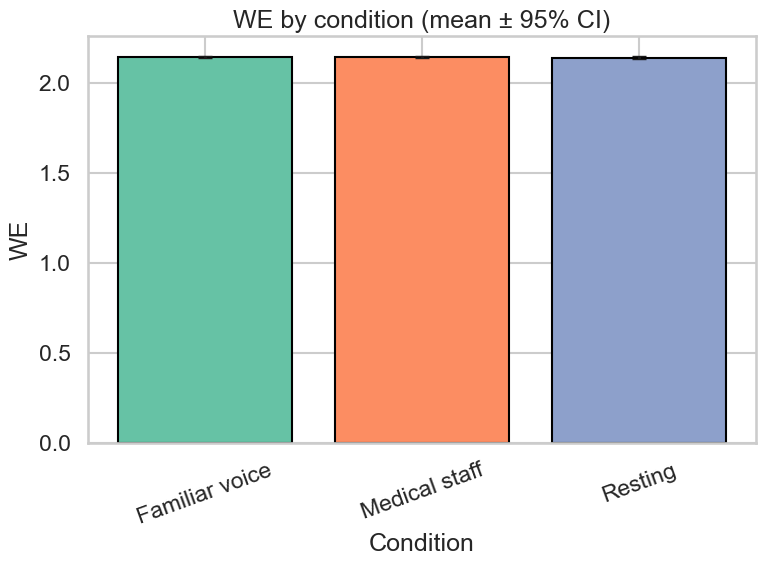

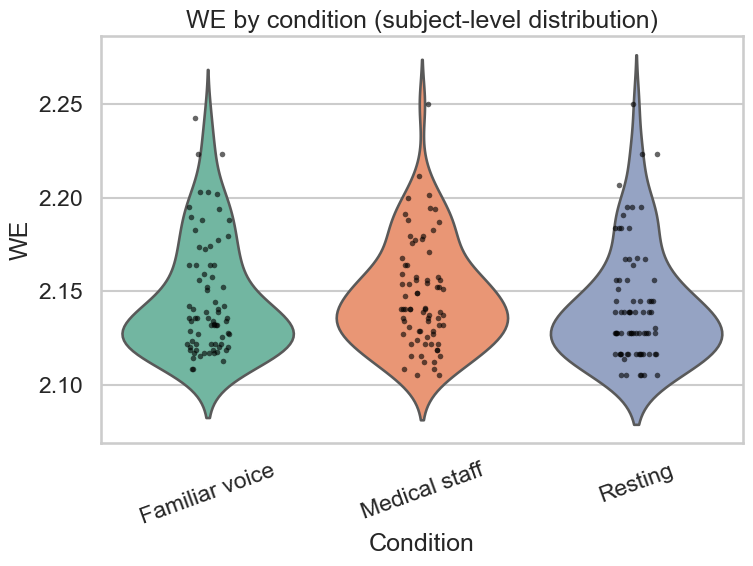

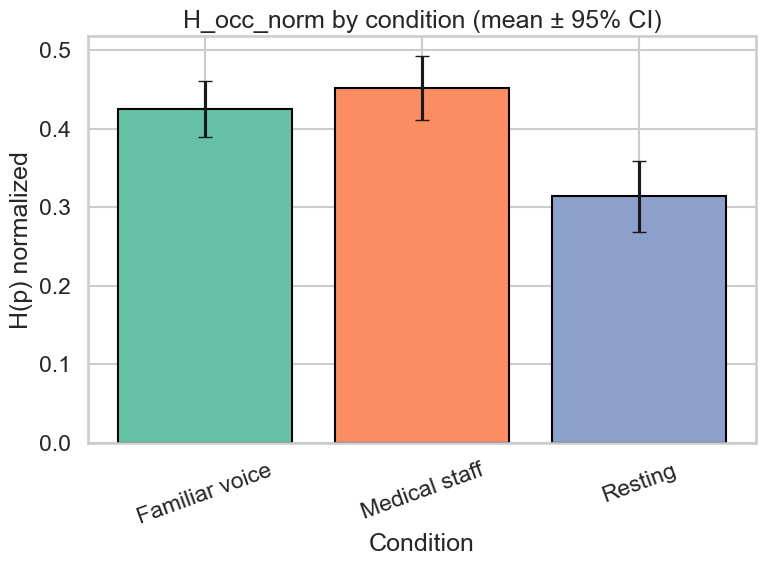

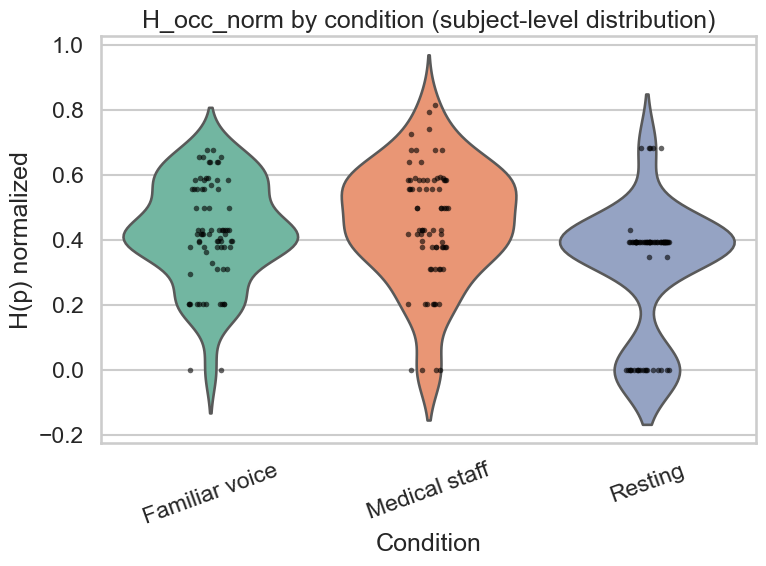

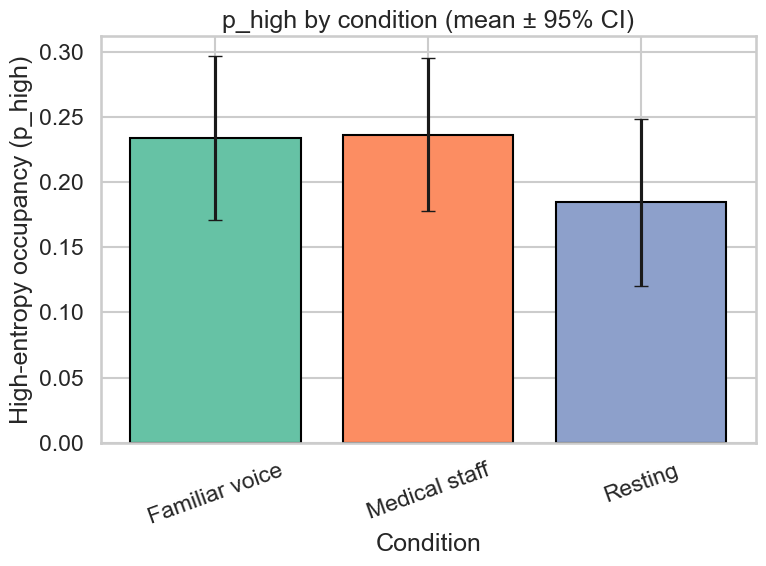

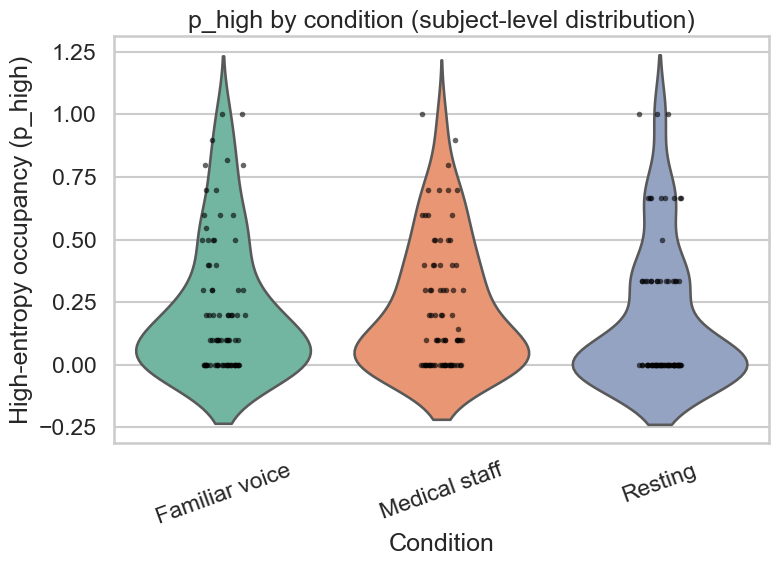

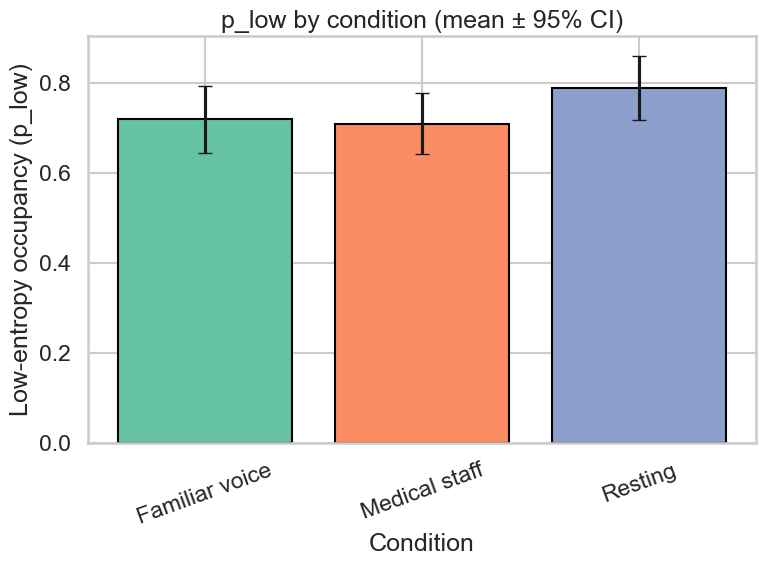

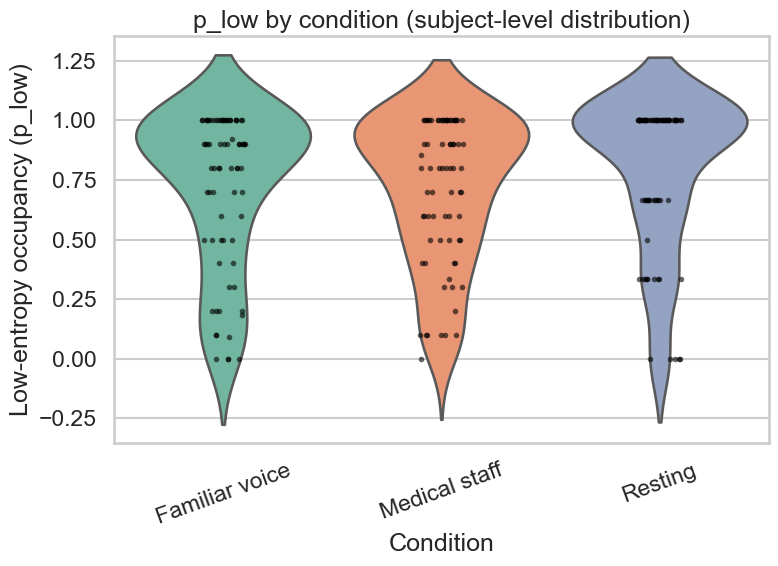

In [244]:
# Helper function for summary stats
def summarize_by_condition(df, metric, condition_col="condition_name"):
    """Compute mean, SD, SEM, and 95% CI for a metric grouped by condition."""
    # Group by condition and aggregate basic statistics
    grouped = df.groupby(condition_col)[metric]  # Group metric by condition
    mean = grouped.mean()  # Mean per condition
    std = grouped.std(ddof=1)  # Sample standard deviation per condition
    n = grouped.count()  # Sample size per condition
    sem = std / np.sqrt(n)  # Standard error of the mean
    ci_half_width = 1.96 * sem  # 95% CI half-width under normal approximation
    ci_low = mean - ci_half_width  # Lower CI bound
    ci_high = mean + ci_half_width  # Upper CI bound

    summary = pd.DataFrame(
        {
            "mean": mean,
            "std": std,
            "sem": sem,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n": n,
        }
    )  # Combine into one DataFrame

    return summary  # Return summary table


# Metrics to summarise
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # Core metrics of interest

summaries = {}  # Dictionary to store summary tables

for metric in metrics:  # Loop through metrics
    summary = summarize_by_condition(df, metric)  # Compute summary stats for this metric
    summaries[metric] = summary  # Store in dictionary
    print(f"\nSummary for {metric}:")  # Announce metric
    display(summary)  # Show summary table in notebook

# Colour palette for conditions
condition_order = sorted(df["condition_name"].unique())  # Determine a stable condition order
palette = sns.color_palette("Set2", n_colors=len(condition_order))  # Choose a qualitative colour palette
condition_to_color = dict(zip(condition_order, palette))  # Map conditions to colours

# Plot function: bar with 95% CI and violin+strip for each metric
def plot_metric_by_condition(df, metric, ylabel):
    """Create bar plot with 95% CI and violin+strip plot for a given metric."""
    summary = summaries[metric]  # Retrieve precomputed summary
    # Ensure summary index matches desired order
    summary = summary.loc[condition_order]  # Reorder to match condition_order

    # --- Bar plot with 95% CI ---
    fig, ax = plt.subplots(figsize=(8, 6))  # Create figure and axis
    ax.bar(
        summary.index,
        summary["mean"],
        yerr=summary["ci_high"] - summary["mean"],
        capsize=5,
        color=[condition_to_color[c] for c in summary.index],
        edgecolor="black",
    )  # Bar plot with CI as error bars

    ax.set_ylabel(ylabel)  # Set y-axis label
    ax.set_xlabel("Condition")  # Set x-axis label
    ax.set_title(f"{metric} by condition (mean ± 95% CI)")  # Set title
    plt.xticks(rotation=20)  # Slight rotation for readability
    plt.tight_layout()  # Adjust layout
    plt.show()  # Display figure

    # --- Violin + strip plot ---
    fig, ax = plt.subplots(figsize=(8, 6))  # New figure for violin plot
    sns.violinplot(
        data=df,
        x="condition_name",
        y=metric,
        order=condition_order,
        palette=condition_to_color,
        inner=None,
        ax=ax,
    )  # Violin plot without internal boxplot
    sns.stripplot(
        data=df,
        x="condition_name",
        y=metric,
        order=condition_order,
        color="black",
        size=4,
        alpha=0.6,
        ax=ax,
    )  # Overlay individual subject×condition points

    ax.set_ylabel(ylabel)  # Set y-axis label
    ax.set_xlabel("Condition")  # Set x-axis label
    ax.set_title(f"{metric} by condition (subject-level distribution)")  # Set title
    plt.xticks(rotation=20)  # Rotate x-axis labels slightly
    plt.tight_layout()  # Adjust layout
    plt.show()  # Display figure


# Create plots for each metric
plot_metric_by_condition(df, "WE", "WE")  # Plot WE
plot_metric_by_condition(df, "H_occ_norm", "H(p) normalized")  # Plot normalised occupancy entropy
plot_metric_by_condition(df, "p_high", "High-entropy occupancy (p_high)")  # Plot high-entropy occupancy
plot_metric_by_condition(df, "p_low", "Low-entropy occupancy (p_low)")  # Plot low-entropy occupancy


## Within-subject statistical tests across conditions

The design is within-subject: each subject contributes data for all three conditions (Familiar voice, Medical staff, Resting).

To follow the spirit of Della Bella et al., condition effects on subject-level metrics are assessed as follows:

1. For each metric, the data are reshaped into a wide format with one row per subject and one column per condition.
2. A non-parametric **Friedman test** is used to test for an overall condition effect.
3. If the Friedman test is significant, **pairwise Wilcoxon signed-rank tests** are conducted between conditions:
   - Familiar vs Medical
   - Familiar vs Resting
   - Medical vs Resting
4. For each pairwise comparison, the following quantities are reported:
   - test statistic and p-value
   - paired Cohen’s \(d\)
   - mean difference and its 95% confidence interval.


In [246]:
# Helper function: reshape to wide subject×condition table
def to_wide(df, metric, subject_col="subject", condition_col="condition_name", condition_order=None):
    """Convert long-form DataFrame to wide format (subjects × conditions) for a given metric."""
    if condition_order is None:  # If no explicit order is provided
        condition_order = sorted(df[condition_col].unique())  # Use sorted unique conditions

    # Pivot to wide format
    wide = df.pivot_table(
        index=subject_col,
        columns=condition_col,
        values=metric,
        aggfunc="mean",
    )  # Wide table with one row per subject

    # Reorder columns to desired condition order
    wide = wide.loc[:, condition_order]  # Ensure consistent column order

    # Drop subjects with any missing values
    wide = wide.dropna(axis=0, how="any")  # Remove subjects lacking any condition

    return wide  # Return wide-format DataFrame


# Helper function: run Friedman + Wilcoxon for one metric
def run_within_subject_tests(df, metric, condition_order):
    """Run Friedman test and Wilcoxon post-hoc comparisons for a metric."""
    print(f"\n=== Within-subject tests for {metric} ===")  # Announce metric

    wide = to_wide(df, metric, condition_order=condition_order)  # Get subject×condition matrix
    print("Wide table shape (subjects × conditions):", wide.shape)  # Show shape

    # Extract values in fixed condition order
    data_arrays = [wide[cond].values for cond in condition_order]  # Collect per-condition arrays

    # Friedman test
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_arrays)  # Run Friedman test
    print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.8f}")  # Print result

    # Create structure for pairwise comparisons
    pairs = [
        (condition_order[0], condition_order[1]),  # Familiar vs Medical
        (condition_order[0], condition_order[2]),  # Familiar vs Resting
        (condition_order[1], condition_order[2]),  # Medical vs Resting
    ]  # Define condition pairs

    results = []  # Collect pairwise results

    for a, b in pairs:  # Loop through condition pairs
        x = wide[a].values  # Values for condition a
        y = wide[b].values  # Values for condition b
        diff = x - y  # Paired differences
        # Wilcoxon signed-rank test
        try:
            stat, p_val = stats.wilcoxon(x, y)  # Perform Wilcoxon test
        except ValueError as e:
            print(f"Wilcoxon failed for {a} vs {b}: {e}")  # Report failure
            continue  # Skip this pair if test cannot be computed

        # Effect size: paired Cohen's d
        diff_mean = diff.mean()  # Mean difference
        diff_std = diff.std(ddof=1)  # Standard deviation of differences
        d = diff_mean / diff_std if diff_std > 0 else np.nan  # Cohen's d

        # 95% CI for mean difference using t-distribution
        n = len(diff)  # Number of paired samples
        sem_diff = diff_std / np.sqrt(n)  # Standard error of mean difference
        t_crit = stats.t.ppf(0.975, df=n - 1)  # Two-sided t critical value
        ci_low = diff_mean - t_crit * sem_diff  # Lower CI bound
        ci_high = diff_mean + t_crit * sem_diff  # Upper CI bound

        results.append(
            {
                "comparison": f"{a} - {b}",
                "statistic": stat,
                "p_value": p_val,
                "cohens_d": d,
                "diff_mean": diff_mean,
                "diff_ci_low": ci_low,
                "diff_ci_high": ci_high,
                "n": n,
            }
        )  # Append results row

    results_df = pd.DataFrame(results)  # Convert results to DataFrame
    display(results_df)  # Show pairwise comparison table

    return friedman_stat, friedman_p, results_df  # Return summary


# Run tests for the main metrics
friedman_results = {}  # Store Friedman and pairwise results per metric

for metric in ["WE", "H_occ_norm", "p_high", "p_low"]:  # Loop through core metrics
    friedman_results[metric] = run_within_subject_tests(df, metric, condition_order)  # Run tests



=== Within-subject tests for WE ===
Wide table shape (subjects × conditions): (75, 3)
Friedman test: chi2 = 2.495, p = 0.28724416


,comparison,statistic,p_value,cohens_d,diff_mean,diff_ci_low,diff_ci_high,n
0,Familiar voice - Medical staff,1170.0,0.418914,-0.089786,-0.001442,-0.005137,0.002253,75
1,Familiar voice - Resting,1049.0,0.097409,0.159784,0.003675,-0.001617,0.008966,75
2,Medical staff - Resting,937.0,0.050711,0.227470,0.005117,-0.000059,0.010292,75



=== Within-subject tests for H_occ_norm ===
Wide table shape (subjects × conditions): (75, 3)
Friedman test: chi2 = 25.444, p = 0.00000298


,comparison,statistic,p_value,cohens_d,diff_mean,diff_ci_low,diff_ci_high,n
0,Familiar voice - Medical staff,978.5,1.709052e-01,-0.138121,-0.026495,-0.070630,0.017640,75
1,Familiar voice - Resting,571.0,1.814681e-05,0.528843,0.111576,0.063034,0.160119,75
2,Medical staff - Resting,424.0,9.838731e-07,0.598406,0.138071,0.084985,0.191158,75



=== Within-subject tests for p_high ===
Wide table shape (subjects × conditions): (75, 3)
Friedman test: chi2 = 7.255, p = 0.02658632


,comparison,statistic,p_value,cohens_d,diff_mean,diff_ci_low,diff_ci_high,n
0,Familiar voice - Medical staff,713.0,0.982259,-0.013719,-0.002390,-0.042465,0.037686,75
1,Familiar voice - Resting,393.5,0.018339,0.226697,0.049737,-0.000742,0.100217,75
2,Medical staff - Resting,427.0,0.041848,0.240993,0.052127,0.002361,0.101893,75



=== Within-subject tests for p_low ===
Wide table shape (subjects × conditions): (75, 3)
Friedman test: chi2 = 15.577, p = 0.00041438


,comparison,statistic,p_value,cohens_d,diff_mean,diff_ci_low,diff_ci_high,n
0,Familiar voice - Medical staff,672.0,0.699071,0.064370,0.009404,-0.024210,0.043019,75
1,Familiar voice - Resting,349.0,0.003228,-0.334178,-0.070278,-0.118664,-0.021892,75
2,Medical staff - Resting,319.5,0.002126,-0.371692,-0.079683,-0.129006,-0.030359,75


## Brain state occupancy profiles across states and conditions

Beyond aggregate measures such as WE and \(H_{\text{occ\_norm}}\), it is informative to visualise how individual brain states contribute to each condition.

In this section:

- Mean occupancy \(p_i\) is computed for each state and condition.
- Standard error and 95% confidence intervals are also derived.
- Two plots are generated:
  1. A line plot of mean occupancy per state, with separate lines for each condition and shaded 95% confidence intervals.
  2. A heatmap of mean occupancy (state × condition), summarising the same information in matrix form.

These visualisations mirror the way Della Bella et al. present brain state occurrence patterns across groups.


,condition_name,state,mean,sem,ci_low,ci_high,n
0,Familiar voice,0,0.012000,0.012000,-0.011520,0.035520,75
1,Familiar voice,1,0.047207,0.018410,0.011124,0.083291,75
2,Familiar voice,2,0.425146,0.030506,0.365353,0.484938,75
3,Familiar voice,3,0.293465,0.032381,0.229999,0.356931,75
4,Familiar voice,4,0.222182,0.030945,0.161530,0.282834,75


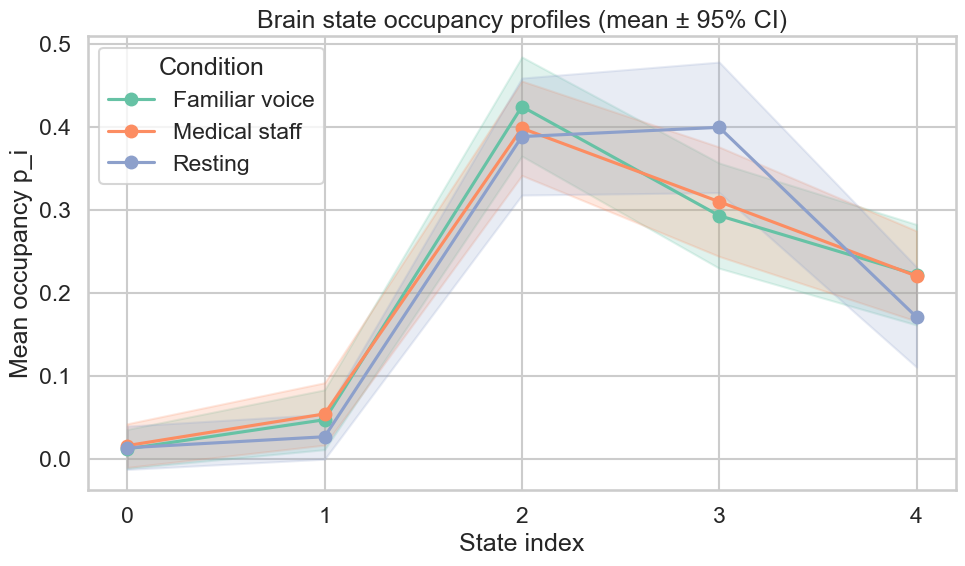

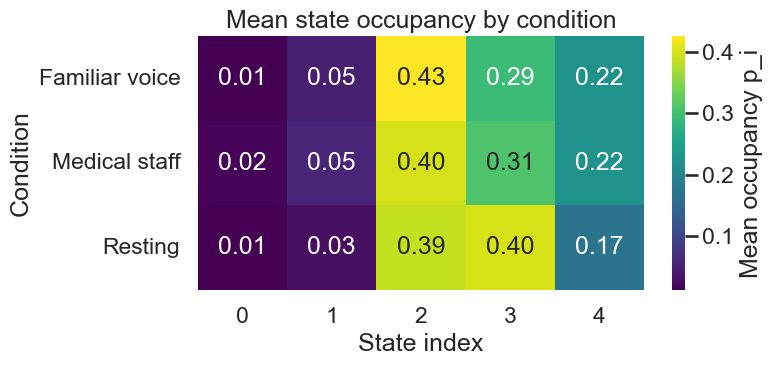

In [247]:
# Compute mean occupancy per state and condition
state_cols = [c for c in df.columns if c.startswith("p_") and c[2:].isdigit()]  # Identify p_i columns

# Build a long-format DataFrame for state occupancy
rows = []  # Collect rows for long-format table
for _, row in df.iterrows():  # Iterate over subject×condition rows
    subj = row["subject"]  # Subject ID
    cond = row["condition_name"]  # Condition name
    for state_col in state_cols:  # Iterate over state occupancy columns
        state_idx = int(state_col.split("_")[1])  # Extract state index from column name
        rows.append(
            {
                "subject": subj,
                "condition_name": cond,
                "state": state_idx,
                "p": row[state_col],
            }
        )  # Append one row per state

df_states_long = pd.DataFrame(rows)  # Create long-format DataFrame

# Summary stats per state × condition
grouped = df_states_long.groupby(["condition_name", "state"])  # Group by condition and state
mean_p = grouped["p"].mean()  # Mean occupancy
std_p = grouped["p"].std(ddof=1)  # Standard deviation
n_p = grouped["p"].count()  # Sample size
sem_p = std_p / np.sqrt(n_p)  # Standard error
ci_half = 1.96 * sem_p  # 95% CI half-width

state_summary = pd.DataFrame(
    {
        "mean": mean_p,
        "sem": sem_p,
        "ci_low": mean_p - ci_half,
        "ci_high": mean_p + ci_half,
        "n": n_p,
    }
).reset_index()  # Reset index to columns

display(state_summary.head())  # Show first rows of summary

# Line plot with 95% CI bands
fig, ax = plt.subplots(figsize=(10, 6))  # Create new figure

for cond in condition_order:  # Loop through conditions in fixed order
    subset = state_summary[state_summary["condition_name"] == cond]  # Subset summary by condition
    subset = subset.sort_values("state")  # Ensure states are in ascending order
    x = subset["state"].values  # State indices
    y = subset["mean"].values  # Mean occupancy
    ci_low = subset["ci_low"].values  # Lower CI bound
    ci_high = subset["ci_high"].values  # Upper CI bound

    ax.plot(
        x,
        y,
        marker="o",
        label=cond,
        color=condition_to_color[cond],
    )  # Plot mean occupancy line
    ax.fill_between(
        x,
        ci_low,
        ci_high,
        alpha=0.2,
        color=condition_to_color[cond],
    )  # Add 95% CI band

ax.set_xlabel("State index")  # Label x-axis
ax.set_ylabel("Mean occupancy p_i")  # Label y-axis
ax.set_title("Brain state occupancy profiles (mean ± 95% CI)")  # Set title
ax.set_xticks(sorted(df_states_long["state"].unique()))  # Show all state indices on x-axis
ax.legend(title="Condition")  # Add legend
plt.tight_layout()  # Adjust layout
plt.show()  # Display figure

# Heatmap of mean occupancy (state × condition)
heatmap_data = state_summary.pivot(
    index="condition_name", columns="state", values="mean"
)  # Pivot to matrix (condition × state)

plt.figure(figsize=(8, 4))  # Create figure for heatmap
sns.heatmap(
    heatmap_data.loc[condition_order],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Mean occupancy p_i"},
)  # Plot heatmap with annotations

plt.title("Mean state occupancy by condition")  # Set title
plt.xlabel("State index")  # Label x-axis
plt.ylabel("Condition")  # Label y-axis
plt.tight_layout()  # Adjust layout
plt.show()  # Display figure


## Notes for the manuscript

The notebook now provides:

- Subject-level descriptive statistics (mean, SEM, 95% CI) for:
  - WE
  - \(H_{\text{occ\_norm}}\)
  - high-entropy occupancy \(p_\text{high}\)
  - low-entropy occupancy \(p_\text{low}\)
- Within-subject non-parametric tests (Friedman + Wilcoxon) comparing conditions for each metric.
- Brain state occupancy profiles across states and conditions, with:
  - line plots (mean ± 95% CI)
  - heatmaps of mean occupancy.

These outputs can be used to construct result tables and figures that closely follow the structure of Della Bella et al., while being adapted to the present within-subject design and k-medoids–based brain states.
